## Generate predictions from models

### Import packages 

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
tfkl = tf.keras.layers
import pandas as pd
from scipy.stats import linregress

### Import functions

In [3]:
import evaluation_functions
import importlib
importlib.reload(evaluation_functions)

<module 'evaluation_functions' from '/Users/paigepark/Desktop/repos/deep-mort/code_single_window/evaluation_functions.py'>

### Import data

In [4]:
country_training = np.loadtxt('../data/country_training_orig.txt')
country_test = np.loadtxt('../data/country_test_orig.txt')

In [5]:
geos_key = np.load('../data/geos_key.npy')
geo_dict = {int(code): geo for geo, code in geos_key}

In [6]:
# convert actual test data to log scale
country_test[:,4][country_test[:,4] == 0] = 9e-06
country_test[:,4] = np.log(country_test[:,4])

### Import predictions

In [7]:
# DL predictions - trained on all countries
dl_test_pred = []
for i in range(1,6):
    dl_test_pred.append(np.loadtxt(f"../data/dl_country_forecast_{i}.txt"))

# LC predictions
# lc_test_pred = []
# for i in range(1,6):
#     lc_test_pred_temp = np.loadtxt(f"../data/lc_forecast_{i}.csv", delimiter=",")
#     lc_test_pred_temp = lc_test_pred_temp[np.lexsort((lc_test_pred_temp[:, 1], lc_test_pred_temp[:, 3], lc_test_pred_temp[:, 2], lc_test_pred_temp[:, 0]))]
#     lc_test_pred_temp[:,4][lc_test_pred_temp[:,4] == 0] = 9e-06
#     lc_test_pred_temp[:,4] = np.log(lc_test_pred_temp[:,4])
#     lc_test_pred.append(lc_test_pred_temp)

# # hyndman-ullah predictions
# hu_test_pred = []
# for i in range(1,6):
#     hu_test_pred_temp = np.loadtxt(f"../data/hu_forecast_{i}.csv", delimiter=",")
#     hu_test_pred_temp = hu_test_pred_temp[np.lexsort((hu_test_pred_temp[:, 1], hu_test_pred_temp[:, 3], hu_test_pred_temp[:, 2], hu_test_pred_temp[:, 0]))]
#     hu_test_pred_temp[:,4][hu_test_pred_temp[:,4] == 0] = 9e-06
#     hu_test_pred_temp[:,4] = np.log(hu_test_pred_temp[:,4])
#     hu_test_pred.append(hu_test_pred_temp)

# coherent predictions
c_test_pred = []
for i in range(1,6):
    c_test_pred_temp = np.genfromtxt(f"../data/coherent_forecast_orig.txt", delimiter=" ")
    c_test_pred_temp = c_test_pred_temp[np.lexsort((c_test_pred_temp[:, 1], c_test_pred_temp[:, 3], c_test_pred_temp[:, 2], c_test_pred_temp[:, 0]))]
    c_test_pred_temp[:,4][c_test_pred_temp[:,4] == 0] = 9e-06
    c_test_pred_temp[:,4] = np.log(c_test_pred_temp[:,4])
    c_test_pred.append(c_test_pred_temp)

# DL predictions - trained on all countries and states
# combined_test_pred = []
# for i in range(1,6):
#     combined_test_pred.append(np.loadtxt(f"../data/dl_combined_forecast_{i}.txt"))

In [8]:
geo_dict_countries_only = dict(list(geo_dict.items())[-40:])

training = country_training.copy()
training[:, 4][training[:, 4] == 0] = 9e-06
training[:, 4] = np.log(training[:, 4])

country_geos = sorted(geo_dict_countries_only.keys())

In [9]:
dl_rmse_by_country = {}
coherent_rmse_by_country = {}

for geo in country_geos:
    # Filter actual test data for this country
    actual_geo = country_test[country_test[:, 0] == geo]
    
    # DL: average RMSE across 5 ensemble members
    dl_rmses = []
    for pred in dl_test_pred:
        pred_geo = pred[pred[:, 0] == geo][:, :5]  # drop uncertainty col
        _, rmse, _ = evaluation_functions.calculate_error(pred_geo, actual_geo)
        dl_rmses.append(rmse)
    dl_rmse_by_country[geo] = np.mean(dl_rmses)
    
    # Coherent: single forecast (all 5 copies are the same file)
    c_pred_geo = c_test_pred[0][c_test_pred[0][:, 0] == geo][:, :5]
    _, rmse, _ = evaluation_functions.calculate_error(c_pred_geo, actual_geo)
    coherent_rmse_by_country[geo] = rmse

print("Per-country RMSE (top 10 by DL improvement ratio):")
for geo in sorted(country_geos, key=lambda g: coherent_rmse_by_country[g] / dl_rmse_by_country[g], reverse=True)[:10]:
    ratio = coherent_rmse_by_country[geo] / dl_rmse_by_country[geo]
    print(f"  {geo_dict[geo]:5s}: DL={dl_rmse_by_country[geo]:.4f}  Coherent={coherent_rmse_by_country[geo]:.4f}  Ratio={ratio:.2f}")

Per-country RMSE (top 10 by DL improvement ratio):
  UKR  : DL=0.1591  Coherent=0.2235  Ratio=1.40
  ESP  : DL=0.2200  Coherent=0.2562  Ratio=1.16
  HUN  : DL=0.2488  Coherent=0.2835  Ratio=1.14
  FIN  : DL=0.3364  Coherent=0.3684  Ratio=1.09
  CHE  : DL=0.3202  Coherent=0.3489  Ratio=1.09
  BEL  : DL=0.2150  Coherent=0.2314  Ratio=1.08
  SVN  : DL=0.6832  Coherent=0.7333  Ratio=1.07
  IRL  : DL=0.3261  Coherent=0.3494  Ratio=1.07
  AUS  : DL=0.1627  Coherent=0.1731  Ratio=1.06
  GBRTENW: DL=0.1434  Coherent=0.1526  Ratio=1.06


In [10]:
rmse_table = pd.DataFrame({
    'Country': [geo_dict[g] for g in country_geos],
    'Coherent RMSE': [coherent_rmse_by_country[g] for g in country_geos],
    'DL RMSE': [dl_rmse_by_country[g] for g in country_geos],
})
rmse_table['Improvement (Coherent \u2212 DL)'] = rmse_table['Coherent RMSE'] - rmse_table['DL RMSE']
rmse_table = rmse_table.sort_values('Improvement (Coherent \u2212 DL)', ascending=False).reset_index(drop=True)

styled = (rmse_table.style
    .format({'Coherent RMSE': '{:.4f}',
             'DL RMSE': '{:.4f}',
             'Improvement (Coherent \u2212 DL)': '{:+.4f}'})
    .background_gradient(subset=['Improvement (Coherent \u2212 DL)'], cmap='RdYlGn', vmin=-rmse_table['Improvement (Coherent \u2212 DL)'].abs().max(), vmax=rmse_table['Improvement (Coherent \u2212 DL)'].abs().max())
    .set_caption('Per-Country RMSE: Coherent vs. DL (sorted by DL improvement)')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13pt'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    ])
    .hide(axis='index'))
styled

Country,Coherent RMSE,DL RMSE,Improvement (Coherent − DL)
UKR,0.2235,0.1591,+0.0644
SVN,0.7333,0.6832,+0.0501
LUX,1.1851,1.1419,+0.0432
EST,0.7427,0.7039,+0.0388
ESP,0.2562,0.2200,+0.0362
HUN,0.2835,0.2488,+0.0347
ISL,1.3569,1.3235,+0.0334
FIN,0.3684,0.3364,+0.0319
CHE,0.3489,0.3202,+0.0287
IRL,0.3494,0.3261,+0.0233


## k(t) Nonlinearity & Absolute RMSE Gap
Lee-Carter linearly extrapolates k(t) from the training period. If the country's k(t) trajectory isn't well-approximated by a line — either through curvature or a mid-training slope change — LC should mis-forecast and DL should win more. Two metrics:
- **k(t) nonlinearity**: std of residuals from a linear fit to k(t), normalized by std(k(t)).
- **k(t) slope change**: |slope(second half) − slope(first half)| / |slope(full)|.

Also re-plotting against the **absolute RMSE gap** (coherent − dl) instead of the ratio, since tiny-population countries (ISL, LUX) have large DL RMSEs that compress their ratios toward 1.

In [11]:
from scipy.stats import pearsonr, spearmanr, linregress

kt_nonlin_by_country = {}
kt_slope_change_by_country = {}

for geo in country_geos:
    geo_data = training[training[:, 0] == geo]
    genders = np.unique(geo_data[:, 1]).astype(int)
    ages = sorted(np.unique(geo_data[:, 3]).astype(int))
    years = sorted(np.unique(geo_data[:, 2]).astype(int))

    nonlin_list, slope_change_list = [], []
    for gender in genders:
        g_data = geo_data[geo_data[:, 1] == gender]
        mat = np.full((len(ages), len(years)), np.nan)
        for j, yr in enumerate(years):
            for i, age in enumerate(ages):
                mask = (g_data[:, 2] == yr) & (g_data[:, 3] == age)
                vals = g_data[mask, 4]
                if len(vals) > 0:
                    mat[i, j] = vals[0]
        if np.isnan(mat).sum() > 0.1 * mat.size:
            continue
        mat = np.nan_to_num(mat, nan=np.nanmean(mat))

        # LC-style decomposition to get k(t)
        ax_mean = mat.mean(axis=1)
        centered = mat - ax_mean[:, None]
        U, S, Vt = np.linalg.svd(centered, full_matrices=False)
        bx = U[:, 0]
        kt = S[0] * Vt[0]
        if bx.sum() < 0:
            bx, kt = -bx, -kt

        t = np.arange(len(years))

        # (a) Residual std from a linear fit to k(t), normalized by std(k(t))
        slope_full, intercept_full, _, _, _ = linregress(t, kt)
        residuals = kt - (slope_full * t + intercept_full)
        nonlin_list.append(np.std(residuals) / (np.std(kt) + 1e-12))

        # (b) Slope change between first and second half
        mid = len(t) // 2
        slope1, _, _, _, _ = linregress(t[:mid], kt[:mid])
        slope2, _, _, _, _ = linregress(t[mid:], kt[mid:])
        slope_change_list.append(abs(slope2 - slope1) / (abs(slope_full) + 1e-12))

    if nonlin_list:
        kt_nonlin_by_country[geo] = np.mean(nonlin_list)
        kt_slope_change_by_country[geo] = np.mean(slope_change_list)

results_kt = pd.DataFrame({
    'geo': list(kt_nonlin_by_country.keys()),
    'country': [geo_dict[g] for g in kt_nonlin_by_country.keys()],
    'kt_nonlinearity': list(kt_nonlin_by_country.values()),
    'kt_slope_change': [kt_slope_change_by_country[g] for g in kt_nonlin_by_country.keys()],
    'dl_rmse': [dl_rmse_by_country[g] for g in kt_nonlin_by_country.keys()],
    'coherent_rmse': [coherent_rmse_by_country[g] for g in kt_nonlin_by_country.keys()],
})
results_kt['improvement_ratio'] = results_kt['coherent_rmse'] / results_kt['dl_rmse']
results_kt['improvement_gap']   = results_kt['coherent_rmse'] - results_kt['dl_rmse']

print('Correlations with improvement RATIO (coherent / dl, >1 = DL wins):')
for metric in ['kt_nonlinearity', 'kt_slope_change']:
    rp, pp = pearsonr(results_kt[metric], results_kt['improvement_ratio'])
    rs, ps = spearmanr(results_kt[metric], results_kt['improvement_ratio'])
    print(f'  {metric:18s}  Pearson r={rp: .3f} (p={pp:.4f})   Spearman r={rs: .3f} (p={ps:.4f})')

print('\nCorrelations with improvement GAP (coherent - dl, >0 = DL wins):')
for metric in ['kt_nonlinearity', 'kt_slope_change']:
    rp, pp = pearsonr(results_kt[metric], results_kt['improvement_gap'])
    rs, ps = spearmanr(results_kt[metric], results_kt['improvement_gap'])
    print(f'  {metric:18s}  Pearson r={rp: .3f} (p={pp:.4f})   Spearman r={rs: .3f} (p={ps:.4f})')

print('\nRe-checking prior metrics against the GAP (rather than the ratio):')
for name, d in [('bx_instability', bx_instability_by_country),
                ('pc1_var_explained', pc1_var_by_country)]:
    geos_shared = [g for g in d if g in kt_nonlin_by_country]
    x = np.array([d[g] for g in geos_shared])
    y = np.array([coherent_rmse_by_country[g] - dl_rmse_by_country[g] for g in geos_shared])
    rp, pp = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    print(f'  {name:18s}  Pearson r={rp: .3f} (p={pp:.4f})   Spearman r={rs: .3f} (p={ps:.4f})')

print()
results_kt.sort_values('kt_nonlinearity', ascending=False)

Correlations with improvement RATIO (coherent / dl, >1 = DL wins):
  kt_nonlinearity     Pearson r= 0.115 (p=0.4784)   Spearman r= 0.154 (p=0.3420)
  kt_slope_change     Pearson r= 0.056 (p=0.7333)   Spearman r= 0.164 (p=0.3114)

Correlations with improvement GAP (coherent - dl, >0 = DL wins):
  kt_nonlinearity     Pearson r= 0.486 (p=0.0015)   Spearman r= 0.385 (p=0.0141)
  kt_slope_change     Pearson r= 0.163 (p=0.3151)   Spearman r= 0.191 (p=0.2373)

Re-checking prior metrics against the GAP (rather than the ratio):


NameError: name 'bx_instability_by_country' is not defined

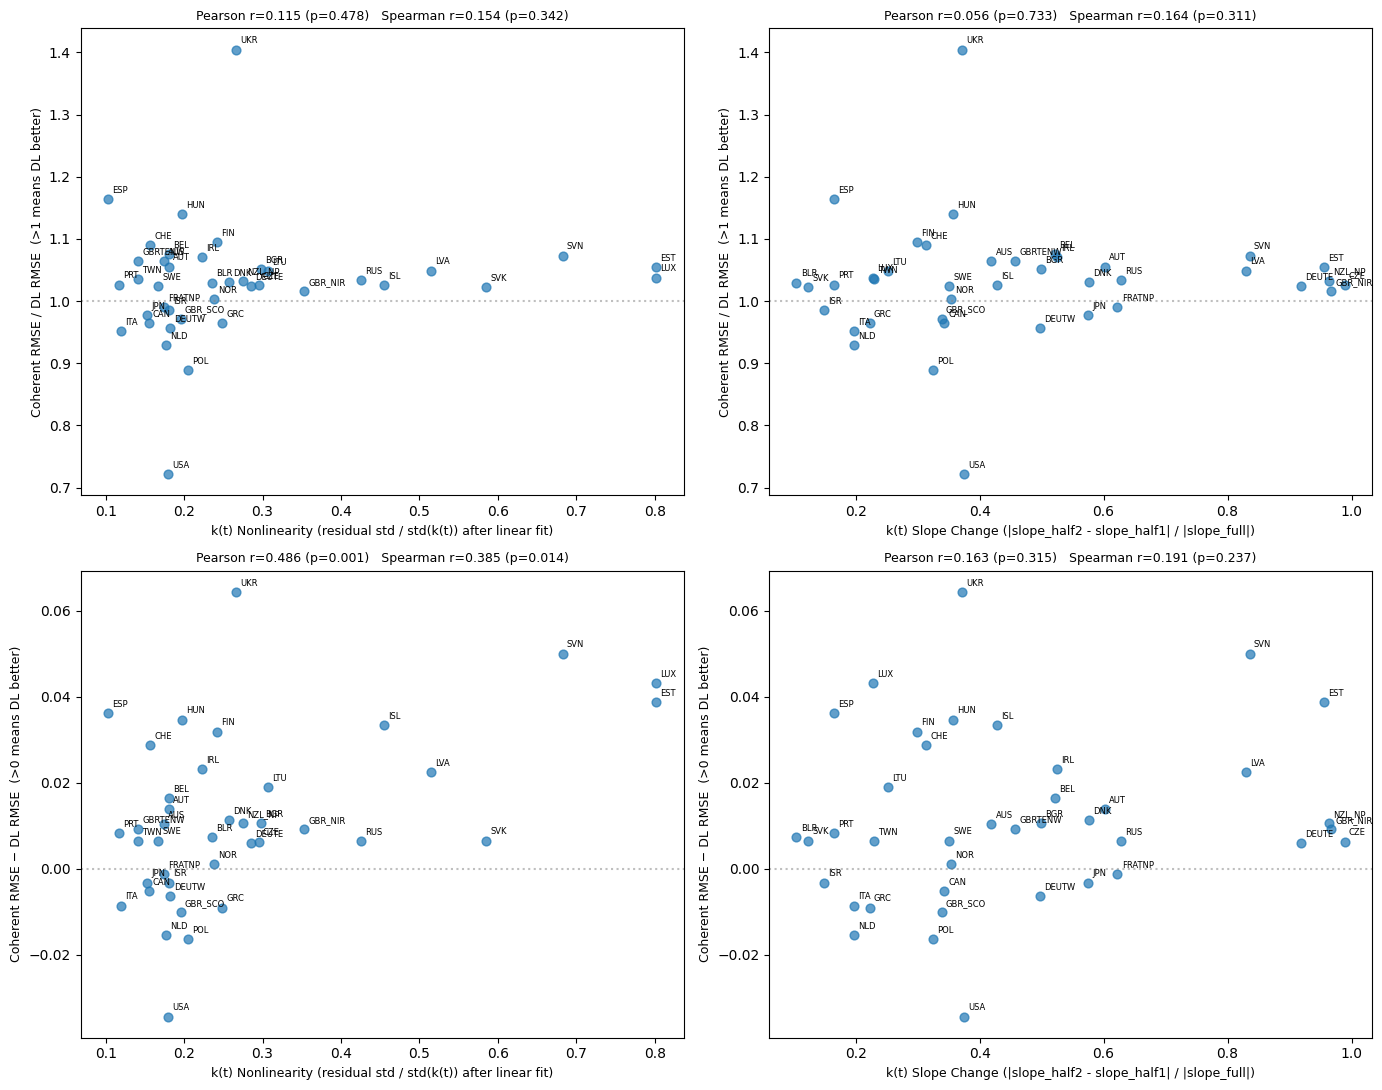

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

panels = [
    ('kt_nonlinearity',  'k(t) Nonlinearity (residual std / std(k(t)) after linear fit)'),
    ('kt_slope_change',  'k(t) Slope Change (|slope_half2 - slope_half1| / |slope_full|)'),
]
y_cols = [
    ('improvement_ratio', 'Coherent RMSE / DL RMSE  (>1 means DL better)', 1.0),
    ('improvement_gap',   'Coherent RMSE \u2212 DL RMSE  (>0 means DL better)', 0.0),
]

for col, (metric, xlabel) in enumerate(panels):
    for row, (ycol, ylabel, yline) in enumerate(y_cols):
        ax = axes[row, col]
        ax.scatter(results_kt[metric], results_kt[ycol], s=40, alpha=0.7)
        for _, r in results_kt.iterrows():
            ax.annotate(r['country'], (r[metric], r[ycol]),
                        fontsize=6, ha='left', va='bottom', xytext=(3, 3),
                        textcoords='offset points')
        ax.axhline(y=yline, color='gray', linestyle=':', alpha=0.5)
        rp, pp = pearsonr(results_kt[metric], results_kt[ycol])
        rs, ps = spearmanr(results_kt[metric], results_kt[ycol])
        ax.set_title(f'Pearson r={rp:.3f} (p={pp:.3f})   Spearman r={rs:.3f} (p={ps:.3f})', fontsize=9)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)

plt.tight_layout()
plt.show()

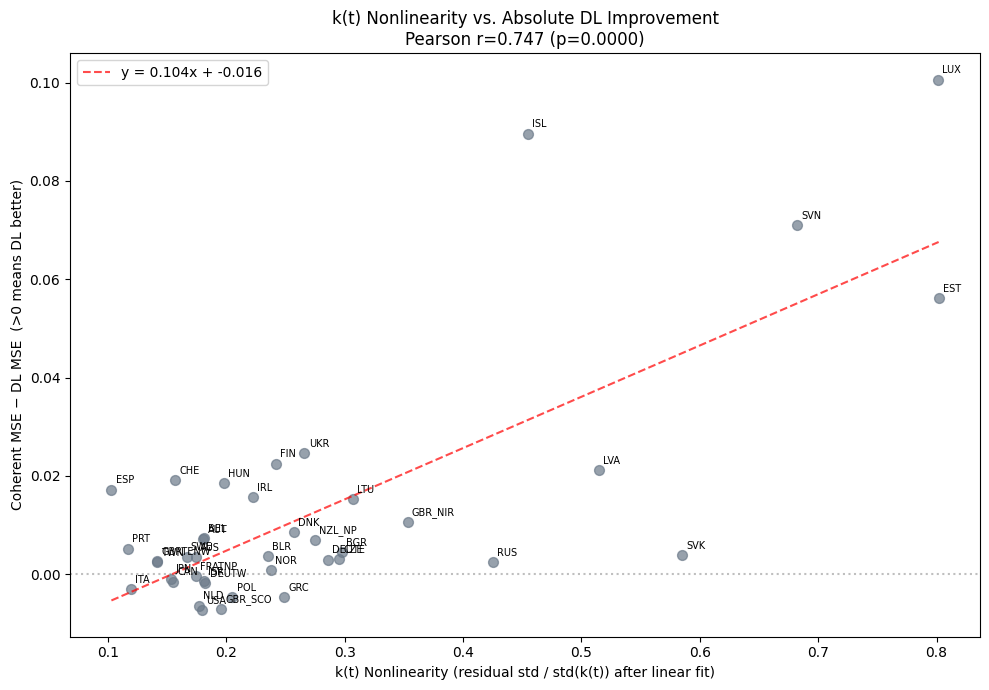

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

results_kt['mse_gap'] = results_kt['coherent_rmse']**2 - results_kt['dl_rmse']**2

ax.scatter(results_kt['kt_nonlinearity'], results_kt['mse_gap'], s=50, alpha=0.7, color='#6C7A89')

for _, r in results_kt.iterrows():
    ax.annotate(r['country'], (r['kt_nonlinearity'], r['mse_gap']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3),
                textcoords='offset points')

slope_kt, intercept_kt, _, _, _ = linregress(results_kt['kt_nonlinearity'], results_kt['mse_gap'])
x_fit = np.linspace(results_kt['kt_nonlinearity'].min(), results_kt['kt_nonlinearity'].max(), 100)
ax.plot(x_fit, slope_kt * x_fit + intercept_kt, 'r--', alpha=0.7, label=f'y = {slope_kt:.3f}x + {intercept_kt:.3f}')

ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

rp, pp = pearsonr(results_kt['kt_nonlinearity'], results_kt['mse_gap'])

ax.set_xlabel('k(t) Nonlinearity (residual std / std(k(t)) after linear fit)')
ax.set_ylabel('Coherent MSE \u2212 DL MSE  (>0 means DL better)')
ax.set_title(f'k(t) Nonlinearity vs. Absolute DL Improvement\n'
             f'Pearson r={rp:.3f} (p={pp:.4f})')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../data/figures/kt_nonlinearity_vs_dl_improvement_gap_mse.png', dpi=300)
plt.show()

## Luxembourg MSE by Age, Year, and Gender

In [90]:
actual_data_divided = []
dl_test_divided = [[] for _ in range(5)]
c_test_divided = [[] for _ in range(5)]

for i in range(50, 90):
    actual_data_divided.append(country_test[country_test[:, 0] == i])

for j in range(5):
    for i in range(50, 90):
        dl_test_divided[j].append(dl_test_pred[j][dl_test_pred[j][:, 0] == i])
        c_test_divided[j].append(c_test_pred[j][c_test_pred[j][:, 0] == i])

In [93]:
geos_key

array([['AK', '0'],
       ['AL', '1'],
       ['AZ', '2'],
       ['AR', '3'],
       ['CA', '4'],
       ['CO', '5'],
       ['CT', '6'],
       ['DE', '7'],
       ['FL', '8'],
       ['GA', '9'],
       ['HI', '10'],
       ['ID', '11'],
       ['IL', '12'],
       ['IN', '13'],
       ['IA', '14'],
       ['KS', '15'],
       ['KY', '16'],
       ['LA', '17'],
       ['ME', '18'],
       ['MD', '19'],
       ['MA', '20'],
       ['MI', '21'],
       ['MN', '22'],
       ['MS', '23'],
       ['MO', '24'],
       ['MT', '25'],
       ['NE', '26'],
       ['NV', '27'],
       ['NH', '28'],
       ['NJ', '29'],
       ['NM', '30'],
       ['NY', '31'],
       ['NC', '32'],
       ['ND', '33'],
       ['OH', '34'],
       ['OK', '35'],
       ['OR', '36'],
       ['PA', '37'],
       ['RI', '38'],
       ['SC', '39'],
       ['SD', '40'],
       ['TN', '41'],
       ['TX', '42'],
       ['UT', '43'],
       ['VT', '44'],
       ['VA', '45'],
       ['WA', '46'],
       ['WV', '47'],
  

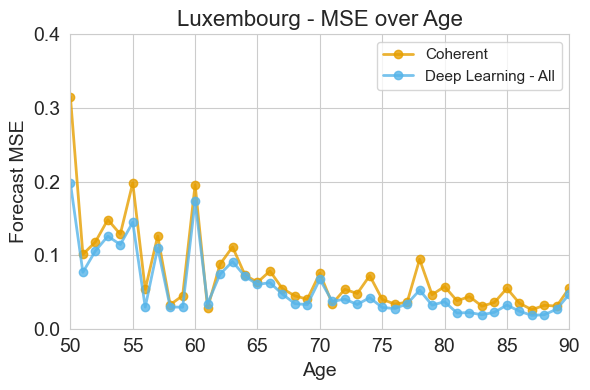

In [111]:
# Luxembourg - MSE over Age only
fig, ax = plt.subplots(figsize=(6, 4))
avg_mses = compute_avg_mses(country_index, 3, models)
for i, (label, data) in enumerate(avg_mses.items()):
    keys, values = zip(*sorted(data.items()))
    ax.plot(keys, values, label=label, linestyle='-', marker='o',
            linewidth=2, alpha=0.8, color=palette[i])
ax.legend(fontsize=11, loc='best', frameon=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_title(f"{country_name} - MSE over Age")
ax.set_xlabel("Age")
ax.set_ylabel("Forecast MSE")
ax.set_xlim(50,90)
ax.set_ylim(0, .4)
plt.tight_layout()
plt.savefig("../data/figures/luxembourg_mse_age.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [ ]:
# Luxembourg - MSE over Year only
fig, ax = plt.subplots(figsize=(6, 4))
avg_mses = compute_avg_mses(country_index, 2, models)
for i, (label, data) in enumerate(avg_mses.items()):
    keys, values = zip(*sorted(data.items()))
    ax.plot(keys, values, label=label, linestyle='-', marker='o',
            linewidth=2, alpha=0.8, color=palette[i])
ax.legend(fontsize=11, loc='best', frameon=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_title(f"{country_name} - MSE over Year")
ax.set_xlabel("Year")
ax.set_ylabel("Forecast MSE")
plt.tight_layout()
plt.savefig("../results/luxembourg_mse_year.pdf", format="pdf", bbox_inches="tight")
plt.show()

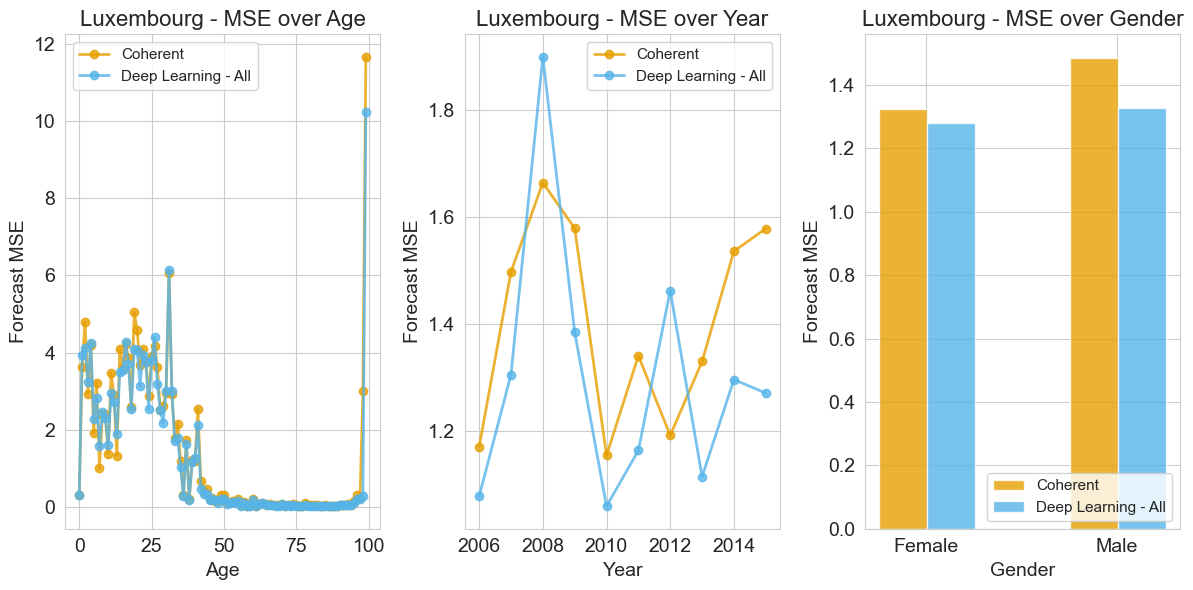

In [107]:
sns.set_style("whitegrid")
palette = ["#E69F00", "#56B4E9", "#009E73"]  # orange, sky blue, green


def compute_avg_mses(country_index, feature_index, models):
    avg_mses = {}
    actual = actual_data_divided

    for label, test_data in models.items():
        mse_list = []
        for i in range(5):
            mse, _, _ = evaluation_functions.calculate_error_by_category(
                test_data[i][country_index],
                actual[country_index],
                feature_index=feature_index,
            )
            mse_list.append(mse)

        combined = {}
        for d in mse_list:
            for k, v in d.items():
                if k not in combined:
                    combined[k] = [v, 1]
                else:
                    combined[k][0] += v
                    combined[k][1] += 1
        avg_mses[label] = {k: total / count for k, (total, count) in combined.items()}

    return avg_mses


country_name = "Luxembourg"
country_index = 26  # LUX (geo code 76, index 76-50 in divided arrays)
features = {"Age": 3, "Year": 2, "Gender": 1}
models = {"Coherent": c_test_divided, "Deep Learning - All": dl_test_divided}

fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=False)
fig.patch.set_alpha(0)

for jdx, (feature_name, feature_index) in enumerate(features.items()):
    avg_mses = compute_avg_mses(country_index, feature_index, models)
    ax = axes[jdx]
    ax.patch.set_alpha(0)

    for i, (label, data) in enumerate(avg_mses.items()):
        keys, values = zip(*sorted(data.items()))

        if feature_index == 1:
            x = np.arange(len(keys)) + i * 0.25
            ax.bar(x, values, width=0.25, label=label, alpha=0.8, color=palette[i])
            gender_labels = ['Female' if k == 0 else 'Male' for k in keys]
            ax.set_xticks(np.arange(len(keys)) + 0.12)
            ax.set_xticklabels(gender_labels)
            ax.legend(fontsize=11, loc='lower right', frameon=True)
        else:
            ax.plot(keys, values, label=label, linestyle='-', marker='o',
                    linewidth=2, alpha=0.8, color=palette[i])
            ax.legend(fontsize=11, loc='best', frameon=True)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

    ax.set_title(f"{country_name} - MSE over {feature_name}")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Forecast MSE")

plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
plt.tight_layout()
plt.savefig("../data/figures/luxembourg_mse.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()